/home/shin101/anaconda3/lib/python3.13/pty.py:95: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  pid, fd = os.forkpty()


/home/shin101/Work/Cosmography Iso


In [1]:
import numpy as np
import pandas as pd
import emcee
import astropy.cosmology as cosmo
import astropy.units as u
from scipy import integrate
from emcee.moves import StretchMove, WalkMove
import pickle
import multiprocessing
import time
from dataclasses import dataclass
from typing import Optional, Tuple, List, Dict, Literal
from pathlib import Path
import warnings
import jax
import jax.numpy as jnp
import numpyro
import numpyro.distributions as dist
from numpyro.infer import MCMC, NUTS
import arviz as az
from cosmographic_expansions.expansions import ExpansionModels
from cosmographic_expansions.transforms import CosmographicTransforms
from cosmographic_expansions.pade import PadeApproximants 
from cosmographic_expansions.expansions import EISModel, EISModelJAX
from cosmographic_expansions.transforms import EISTransforms
import scienceplots
from astropy.constants import c

import matplotlib.pyplot as plt
plt.style.use(['science', 'notebook', 'grid'])
numpyro.set_platform("gpu")

In [2]:
url='https://raw.githubusercontent.com/PantheonPlusSH0ES/DataRelease/main/Pantheon%2B_Data/4_DISTANCES_AND_COVAR/Pantheon%2BSH0ES.dat'
df = pd.read_csv(url, delim_whitespace=True)
z = df['zCMB'].to_numpy()
mu_obs = df['MU_SH0ES'].to_numpy()

dl = 10**(mu_obs/5 + 1) * u.pc.to(u.Mpc)
mu_err = df['MU_SH0ES_ERR_DIAG'].to_numpy()
dl_err = (np.log(10)/5) * dl * mu_err

/tmp/ipykernel_19291/753680998.py:2: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(url, delim_whitespace=True)


In [13]:
H0 = 70
Om_true: float = 0.334
Ok_true: float = 0.0
w_true: float = -1.0

H0_range: Tuple[float, float] = (50.0, 90.0)
q0_range: Tuple[float, float] = (-10.0, 10.0)
j0_range: Tuple[float, float] = (-10.0, 10.0)
s0_range: Tuple[float, float] = (-10.0, 10.0)
c0_range: Tuple[float, float] = (-10.0, 20.0)
p0_range: Tuple[float, float] = (-30.0, 10.0)
z_jax = jnp.array(z)
c_kmps: float = c.to(u.km / u.s).value  # Speed of light in km/s
#data_jax = jnp.array(data)
def get_prior_ranges():
    return [H0_range, q0_range, j0_range, s0_range, c0_range, p0_range]

E1_range: Tuple[float, float] = (-10.0, 10.0)
E2_range: Tuple[float, float] = (-10.0, 10.0)
E3_range: Tuple[float, float] = (-10.0, 10.0)
E4_range: Tuple[float, float] = (-20.0, 15.0)
E5_range: Tuple[float, float] = (-30.0, 10.0)
def get_prior_ranges_eis():
    return [H0_range, E1_range, E2_range, E3_range, E4_range, E5_range]

In [ ]:

# prior_ranges = get_prior_ranges()

# param_names = ['H0', 'q0', 'j0', 's0', 'c0', 'p0']
# params = []
# for i in range(0, 6):
#     key = jax.random.PRNGKey(np.random.randint(0, 1e6))  # Different seed for each order

#     param = numpyro.sample(param_names[i], dist.Uniform(prior_ranges[i][0], prior_ranges[i][1]),rng_key=key)
#     params.append(param)
#     print(params)

: 

In [15]:
def numpyro_model(z_jax,dl,mu_err,order):
    prior_ranges = get_prior_ranges()
    param_names = ['H0', 'q0', 'j0', 's0', 'c0', 'p0']
    params = []
    for i in range(0, order):
        param = numpyro.sample(param_names[i], dist.Uniform(prior_ranges[i][0], prior_ranges[i][1]))
        params.append(param)
    model_dl  = jnp.array(ExpansionModels.log_series(jnp.log(1+z_jax), *[params[i] for i in range(0,order)], order=order))
    #model_dl  = jnp.array(EISModelJAX.luminosity_distance(z_jax, *[params[i] for i in range(0,order)], order=order))
    dl_err_jax = jnp.array((np.log(10)/5) * dl * mu_err)
    numpyro.sample('obs', dist.Normal(model_dl, dl_err_jax), obs=jnp.array(dl))
def numpyro_EIS_model(z_jax,dl,mu_err,order):
    prior_ranges = get_prior_ranges_eis()
    param_names = ['H0', 'E1', 'E2', 'E3', 'E4', 'E5']
    params = []
    for i in range(0, order):
        param = numpyro.sample(param_names[i], dist.Uniform(prior_ranges[i][0], prior_ranges[i][1]))
        params.append(param)
    #model_dl  = jnp.array(ExpansionModels.log_series(jnp.log(1+z_jax), *[params[i] for i in range(0,order)], order=order))
    model_dl  = jnp.array(EISModelJAX.luminosity_distance(z_jax, *[params[i] for i in range(0,order)], order=order))
    dl_err_jax = jnp.array((np.log(10)/5) * dl * mu_err)
    numpyro.sample('obs', dist.Normal(model_dl, dl_err_jax), obs=jnp.array(dl))

In [ ]:
#jax.config.update("jax_log_compiles", False)

In [16]:
pade_models = PadeApproximants()
def get_pade_functions( order: int) :
    """Get appropriate Pade approximants for given order"""
    if order < 3:
        return []
    elif order == 3:
        return [pade_models.pade_21]
    elif order == 4:
        return [pade_models.pade_22]
    elif order == 5:
        return [pade_models.pade_32, pade_models.pade_average]
    else:  # order >= 6
        return [pade_models.pade_42,pade_models.pade_51]

In [ ]:
results = {}
for order in range(4, 5):
    print(f"\n{'='*50}")
    print(f"Running MCMC for order {order}")
    print(f"{'='*50}\n")
    
    nuts_kernel = NUTS(numpyro_EIS_model,target_accept_prob=0.90)
    mcmc = MCMC(nuts_kernel, num_warmup=500, num_samples=2000, num_chains=2, progress_bar=True, chain_method='vectorized')
    key = jax.random.PRNGKey(order)  # Different seed for each order
    mcmc.run(key, z_jax, dl, mu_err, order)
    mcmc.print_summary()
    
    results[order] = {
        'mcmc': mcmc,
        'idata': az.from_numpyro(mcmc)
    }


Running MCMC for order 4



warmup:   0%|          | 1/2500 [00:05<4:01:01,  5.79s/it]

In [ ]:
idata = az.from_numpyro(results[3]['mcmc'])
az.plot_pair(
    idata,
    var_names=["H0","E1","E2"],
    kind="kde",
    marginals=True
)

In [163]:
results = {}
for order in range(6, 7):
    print(f"\n{'='*50}")
    print(f"Running MCMC for order {order}")
    print(f"{'='*50}\n")
    
    nuts_kernel = NUTS(numpyro_model)
    mcmc = MCMC(nuts_kernel, num_warmup=300, num_samples=3000, num_chains=2, progress_bar=True, chain_method='vectorized')
    key = jax.random.PRNGKey(order)  # Different seed for each order
    mcmc.run(key, z_jax, dl, mu_err, order)
    mcmc.print_summary()
    
    results[order] = {
        'mcmc': mcmc,
        'idata': az.from_numpyro(mcmc)
    }


Running MCMC for order 6



sample: 100%|██████████| 3300/3300 [01:36<00:00, 34.13it/s]



                mean       std    median      5.0%     95.0%     n_eff     r_hat
        H0     72.88      0.31     72.88     72.41     73.44    540.81      1.00
        c0      3.80      5.69      3.35     -6.01     13.51    755.75      1.00
        j0      0.63      0.55      0.61     -0.39      1.47    296.54      1.00
        p0     -9.49     11.29     -8.94    -25.70      9.57   1471.59      1.00
        q0     -0.40      0.08     -0.40     -0.52     -0.27    297.08      1.01
        s0     -1.55      2.59     -1.42     -6.07      2.64   1019.70      1.00

Number of divergences: 177


In [161]:
results[6]

{'mcmc': <numpyro.infer.mcmc.MCMC at 0x7f6559e91450>,
 'idata': Inference data with groups:
 	> posterior
 	> log_likelihood
 	> sample_stats
 	> observed_data}

/home/shin101/anaconda3/lib/python3.13/site-packages/arviz/stats/density_utils.py:488: UserWarning: Your data appears to have a single value or no finite values
  warnings.warn("Your data appears to have a single value or no finite values")
/home/shin101/anaconda3/lib/python3.13/site-packages/arviz/stats/density_utils.py:488: UserWarning: Your data appears to have a single value or no finite values
  warnings.warn("Your data appears to have a single value or no finite values")
/home/shin101/anaconda3/lib/python3.13/site-packages/arviz/stats/density_utils.py:488: UserWarning: Your data appears to have a single value or no finite values
  warnings.warn("Your data appears to have a single value or no finite values")


array([[<Axes: title={'center': 'E1'}>, <Axes: title={'center': 'E1'}>],
       [<Axes: title={'center': 'E2'}>, <Axes: title={'center': 'E2'}>],
       [<Axes: title={'center': 'H0'}>, <Axes: title={'center': 'H0'}>]],
      dtype=object)

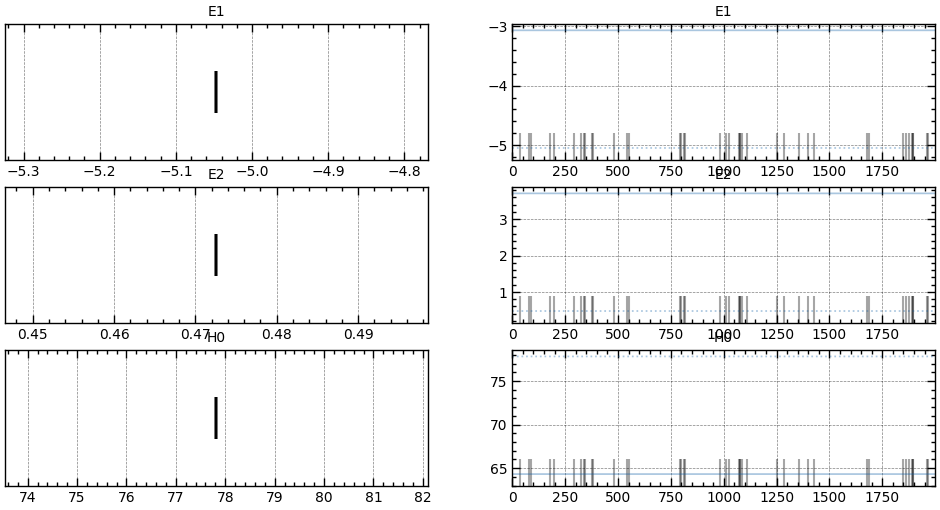

In [20]:
idata = az.from_numpyro(results[3]['mcmc'])
az.plot_trace(results[3]['idata'])

In [176]:
idata = az.from_numpyro(results[6]['mcmc'])
print("Divergences =", idata.sample_stats["diverging"].sum().item())
div_mask = np.array(idata.sample_stats["diverging"], dtype=bool)
print("Indices of divergences:", np.nonzero(div_mask)[0][:20])


Divergences = 6
Indices of divergences: [0 0 0 1 1 1]


array([[<Axes: ylabel='c0'>, <Axes: >, <Axes: >, <Axes: >, <Axes: >],
       [<Axes: ylabel='j0'>, <Axes: >, <Axes: >, <Axes: >, <Axes: >],
       [<Axes: ylabel='p0'>, <Axes: >, <Axes: >, <Axes: >, <Axes: >],
       [<Axes: ylabel='q0'>, <Axes: >, <Axes: >, <Axes: >, <Axes: >],
       [<Axes: xlabel='H0', ylabel='s0'>, <Axes: xlabel='c0'>,
        <Axes: xlabel='j0'>, <Axes: xlabel='p0'>, <Axes: xlabel='q0'>]],
      dtype=object)

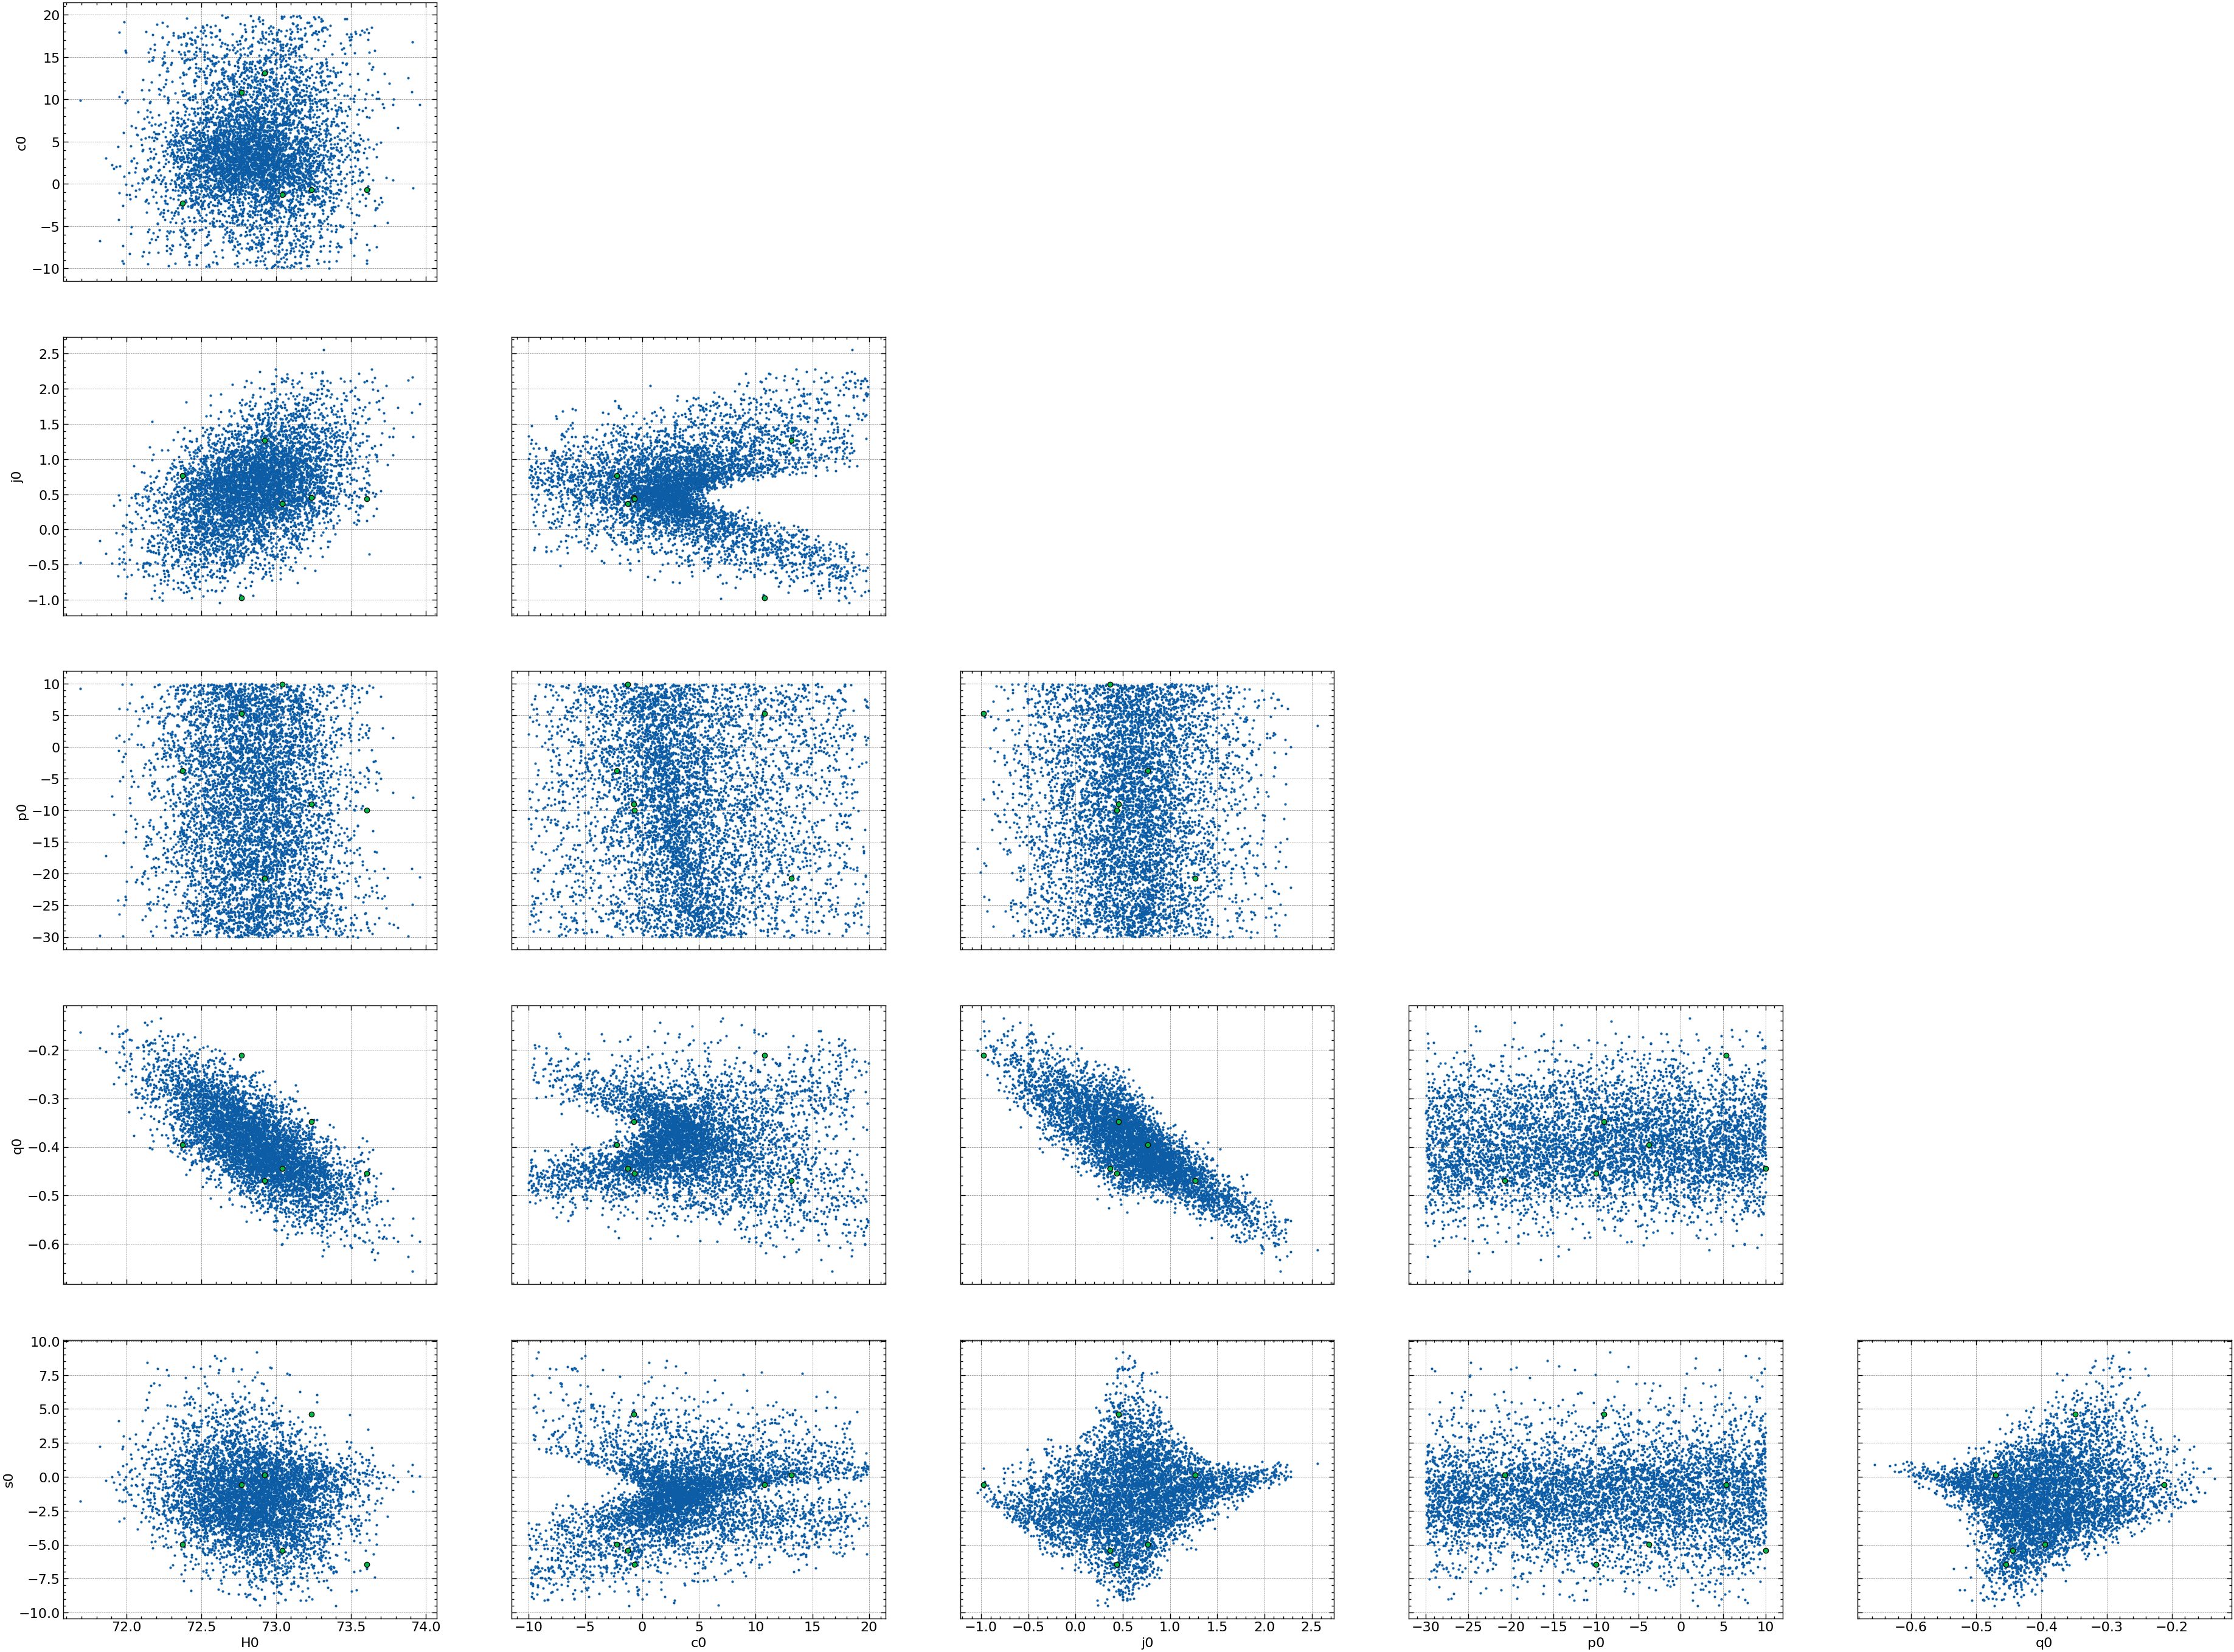

In [177]:
az.plot_pair(
    idata,
    var_names=list(results[6]['mcmc'].get_samples().keys()),
    divergences=True
)

In [173]:
import numpy as np, arviz as az
idata = az.from_numpyro(results[6]['mcmc'])
div_mask = np.array(idata.sample_stats["diverging"], dtype=bool)

print("TOTAL divergences:", div_mask.sum())
div_mask = div_mask.ravel()
# show the unique sample indices that diverged (first 50)
div_idx = np.nonzero(div_mask)[0]
print("Divergent draw indices (unique):", np.unique(div_idx)[:50])

# How many distinct parameter vectors among divergences?
samples = {k: np.array(v) for k, v in results[6]['mcmc'].get_samples().items()}
div_samples = {k: samples[k][div_mask] for k in samples}
# If all rows identical, the unique rows count will be 1:
stacked = np.column_stack([div_samples[k] for k in sorted(div_samples)])
print("Number of unique diverging parameter vectors:",
      np.unique(stacked.round(decimals=8), axis=0).shape[0])

# Compare means of divergent vs non-divergent
for k in sorted(samples):
    print(f"{k}: mean(non-div)={samples[k][~div_mask].mean():.4g}, mean(div)={samples[k][div_mask].mean():.4g}, std(div)={samples[k][div_mask].std():.4g}")


TOTAL divergences: 177
Divergent draw indices (unique): [   3   65   67   68   72  100  112  115  121  122  127  129  201  238
  325  361  406  408  412  416  418  419  422  426  432  433  447  473
  500  502  503  504  505  579  586  592  593  637  657  730  762  780
  795  800  858  884 1064 1113 1114 1125]
Number of unique diverging parameter vectors: 168
H0: mean(non-div)=72.88, mean(div)=73.03, std(div)=0.3832
c0: mean(non-div)=3.673, mean(div)=8.11, std(div)=6.946
j0: mean(non-div)=0.6243, mean(div)=0.9339, std(div)=0.8725
p0: mean(non-div)=-9.378, mean(div)=-13.02, std(div)=11.39
q0: mean(non-div)=-0.3995, mean(div)=-0.4448, std(div)=0.116
s0: mean(non-div)=-1.572, mean(div)=-0.792, std(div)=3.165


In [171]:
for i, idx in enumerate(np.nonzero(div_mask)[0][:10]):
    print(f"Sample {idx}:")
    for p in samples:
        print(f"  {p}: {samples[p][idx]}")

Sample 0:
  H0: 72.86168670654297
  c0: -7.1849517822265625
  j0: 1.157465934753418
  p0: -10.376340866088867
  q0: -0.4732952117919922
  s0: -3.467273712158203
Sample 0:
  H0: 72.86168670654297
  c0: -7.1849517822265625
  j0: 1.157465934753418
  p0: -10.376340866088867
  q0: -0.4732952117919922
  s0: -3.467273712158203
Sample 0:
  H0: 72.86168670654297
  c0: -7.1849517822265625
  j0: 1.157465934753418
  p0: -10.376340866088867
  q0: -0.4732952117919922
  s0: -3.467273712158203
Sample 0:
  H0: 72.86168670654297
  c0: -7.1849517822265625
  j0: 1.157465934753418
  p0: -10.376340866088867
  q0: -0.4732952117919922
  s0: -3.467273712158203
Sample 0:
  H0: 72.86168670654297
  c0: -7.1849517822265625
  j0: 1.157465934753418
  p0: -10.376340866088867
  q0: -0.4732952117919922
  s0: -3.467273712158203
Sample 0:
  H0: 72.86168670654297
  c0: -7.1849517822265625
  j0: 1.157465934753418
  p0: -10.376340866088867
  q0: -0.4732952117919922
  s0: -3.467273712158203
Sample 0:
  H0: 72.86168670654297


In [170]:
np.mean(idata.sample_stats["step_size"])

KeyError: "No variable named 'step_size'. Variables on the dataset include ['chain', 'draw', 'diverging']"

In [169]:
az.plot_energy(idata)


AttributeError: 'Dataset' object has no attribute 'energy'

In [168]:
samples = {k: np.array(v) for k,v in results[6]['mcmc'].get_samples().items()}

for param in samples:
    print(param)
    print("  mean (nondiv):", samples[param][~div_mask].mean())
    print("  mean (div   ):", samples[param][ div_mask].mean())
    print()


H0


IndexError: too many indices for array: array is 1-dimensional, but 2 were indexed

In [166]:
print("BFMI:", az.bfmi(idata))

TypeError: Energy variable was not found.

In [52]:
idata.sample_stats["diverging"].sum()

<xarray.DataArray 'diverging' ()> Size: 8B
array(73)

In [184]:
az.bfmi(idata)

TypeError: Energy variable was not found.

/home/shin101/anaconda3/lib/python3.13/site-packages/arviz/plots/plot_utils.py:270: UserWarning: rcParams['plot.max_subplots'] (40) is smaller than the number of variables to plot (192) in plot_autocorr, generating only 40 plots
  warnings.warn(


array([[<Axes: title={'center': 'H0\n0'}>,
        <Axes: title={'center': 'H0\n1'}>,
        <Axes: title={'center': 'H0\n2'}>,
        <Axes: title={'center': 'H0\n3'}>],
       [<Axes: title={'center': 'H0\n4'}>,
        <Axes: title={'center': 'H0\n5'}>,
        <Axes: title={'center': 'H0\n6'}>,
        <Axes: title={'center': 'H0\n7'}>],
       [<Axes: title={'center': 'H0\n8'}>,
        <Axes: title={'center': 'H0\n9'}>,
        <Axes: title={'center': 'H0\n10'}>,
        <Axes: title={'center': 'H0\n11'}>],
       [<Axes: title={'center': 'H0\n12'}>,
        <Axes: title={'center': 'H0\n13'}>,
        <Axes: title={'center': 'H0\n14'}>,
        <Axes: title={'center': 'H0\n15'}>],
       [<Axes: title={'center': 'H0\n16'}>,
        <Axes: title={'center': 'H0\n17'}>,
        <Axes: title={'center': 'H0\n18'}>,
        <Axes: title={'center': 'H0\n19'}>],
       [<Axes: title={'center': 'H0\n20'}>,
        <Axes: title={'center': 'H0\n21'}>,
        <Axes: title={'center': 'H0\n

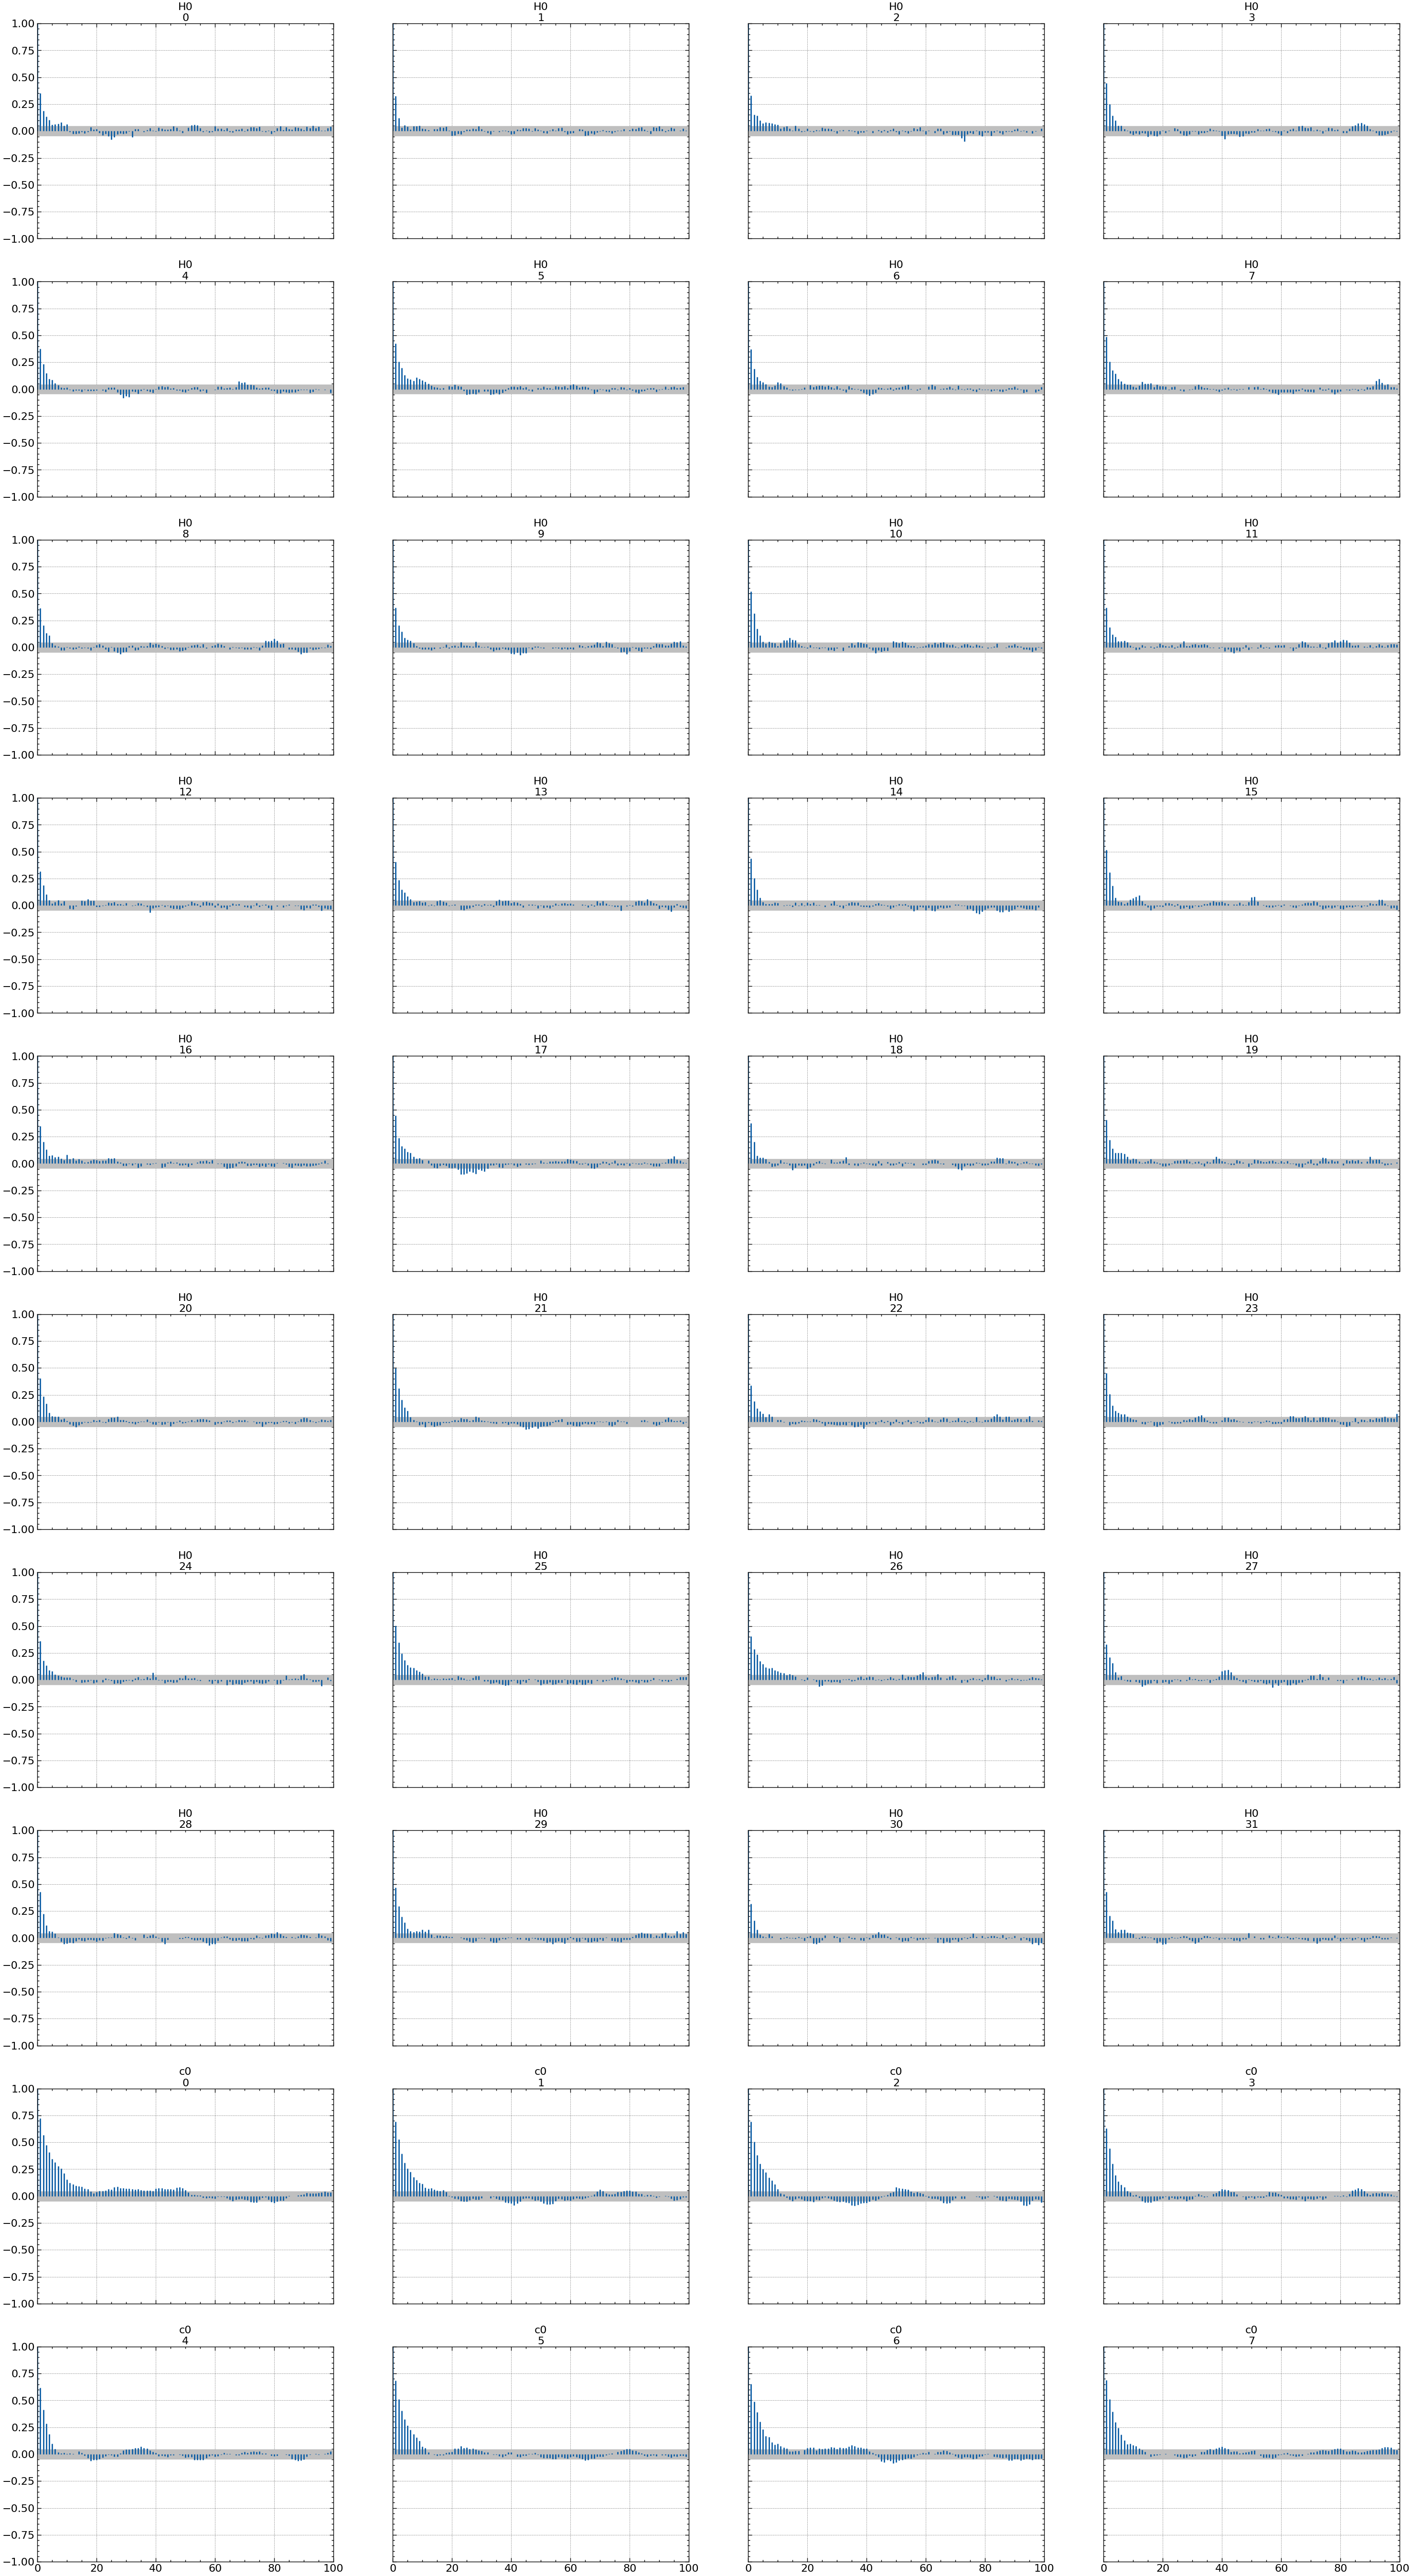

In [53]:
az.plot_autocorr(idata)

array([[<Axes: title={'center': 'H0'}, xlabel='Rank (all chains)', ylabel='Chain'>,
        <Axes: title={'center': 'c0'}, xlabel='Rank (all chains)', ylabel='Chain'>,
        <Axes: title={'center': 'j0'}, xlabel='Rank (all chains)', ylabel='Chain'>],
       [<Axes: title={'center': 'p0'}, xlabel='Rank (all chains)', ylabel='Chain'>,
        <Axes: title={'center': 'q0'}, xlabel='Rank (all chains)', ylabel='Chain'>,
        <Axes: title={'center': 's0'}, xlabel='Rank (all chains)', ylabel='Chain'>]],
      dtype=object)

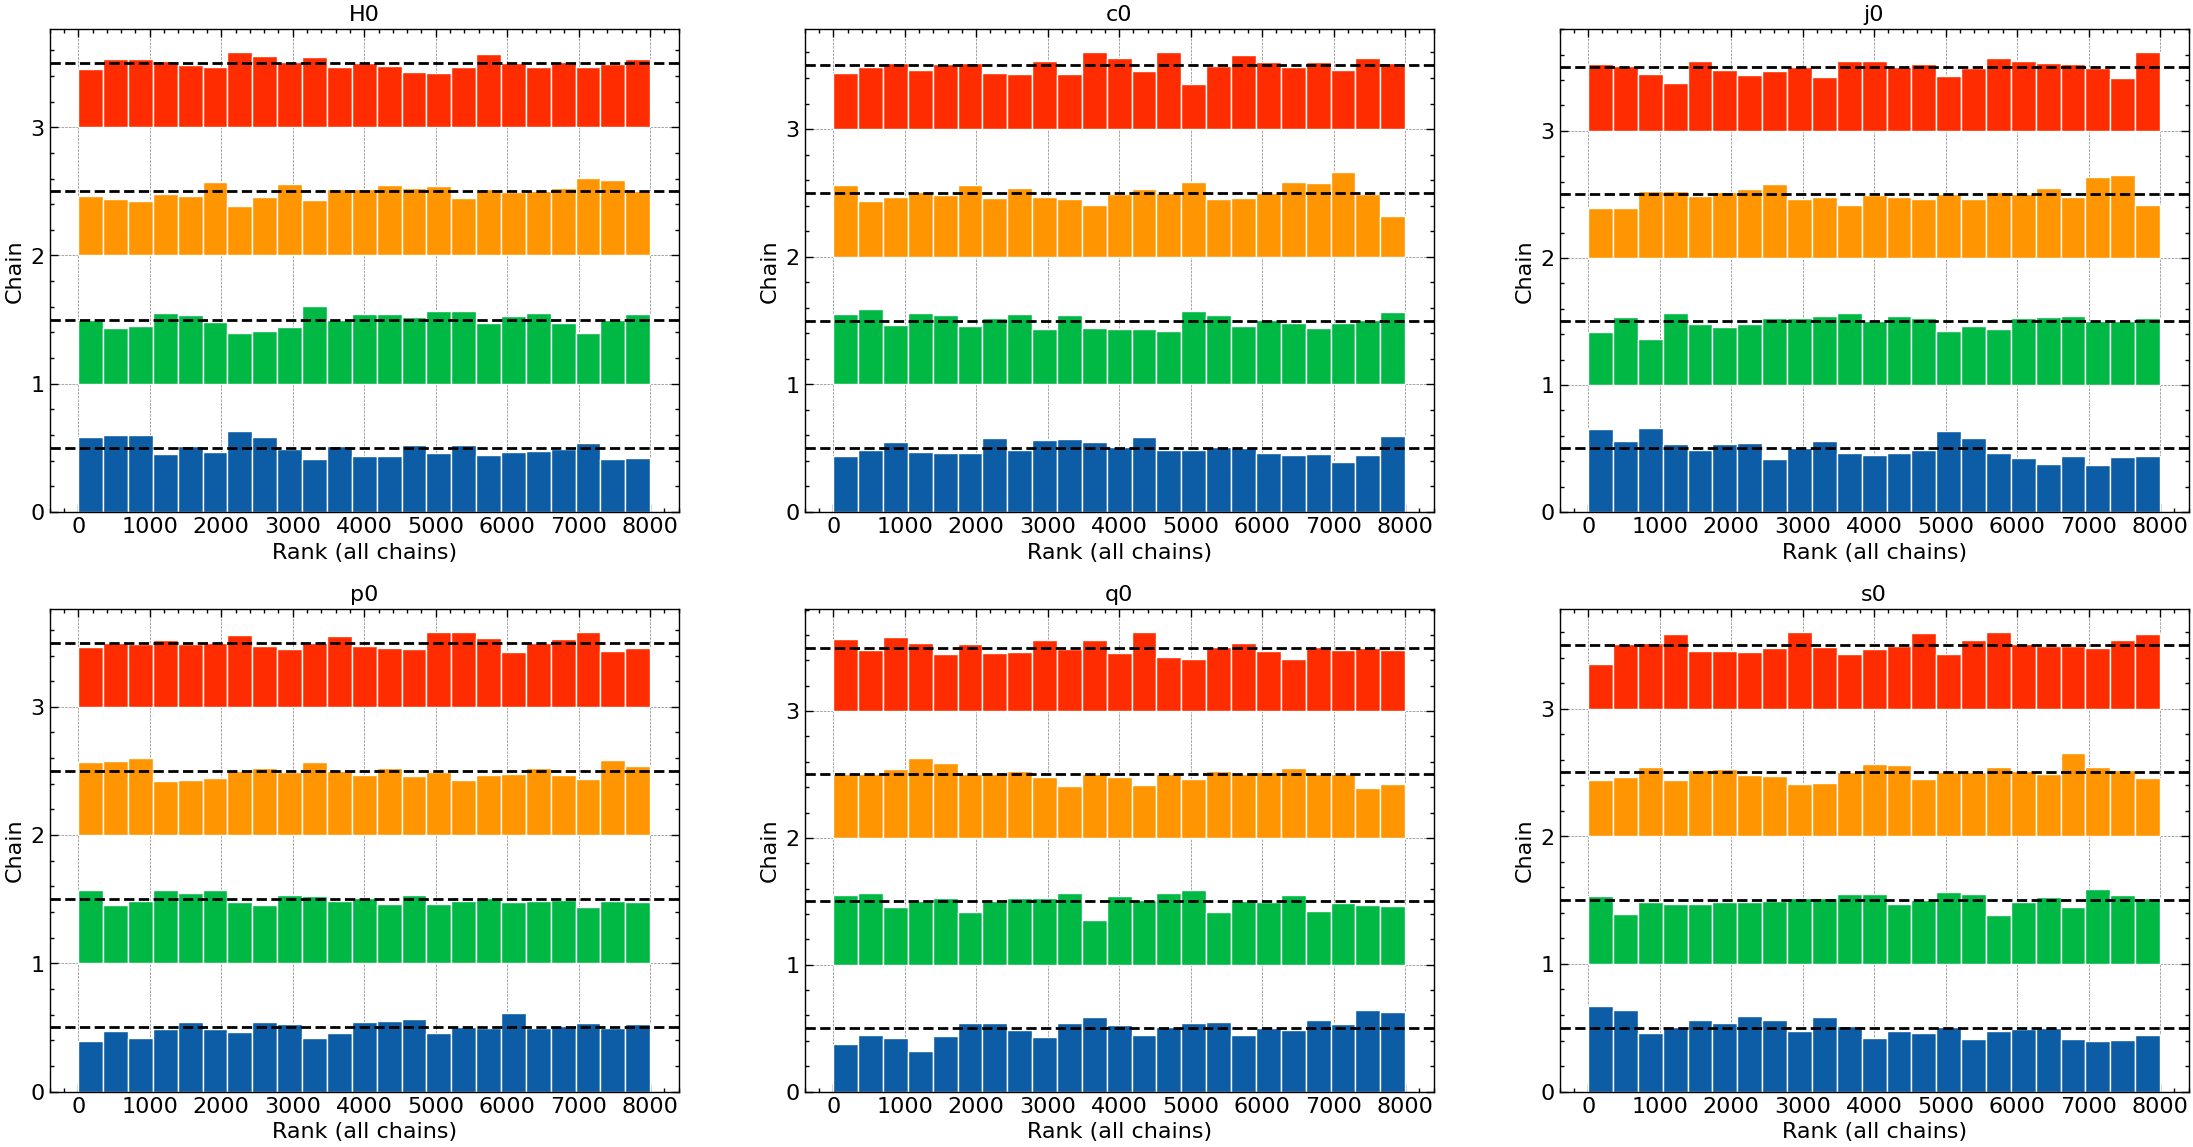

In [48]:
az.plot_rank(idata)

In [43]:
az.ess(idata)

<xarray.Dataset> Size: 48B
Dimensions:  ()
Data variables:
    H0       float64 8B 2.597e+03
    c0       float64 8B 1.252e+03
    j0       float64 8B 967.0
    p0       float64 8B 4.973e+03
    q0       float64 8B 1.192e+03
    s0       float64 8B 1.122e+03

array([[<Axes: title={'center': 'H0'}>, <Axes: title={'center': 'c0'}>,
        <Axes: title={'center': 'j0'}>],
       [<Axes: title={'center': 'p0'}>, <Axes: title={'center': 'q0'}>,
        <Axes: title={'center': 's0'}>]], dtype=object)

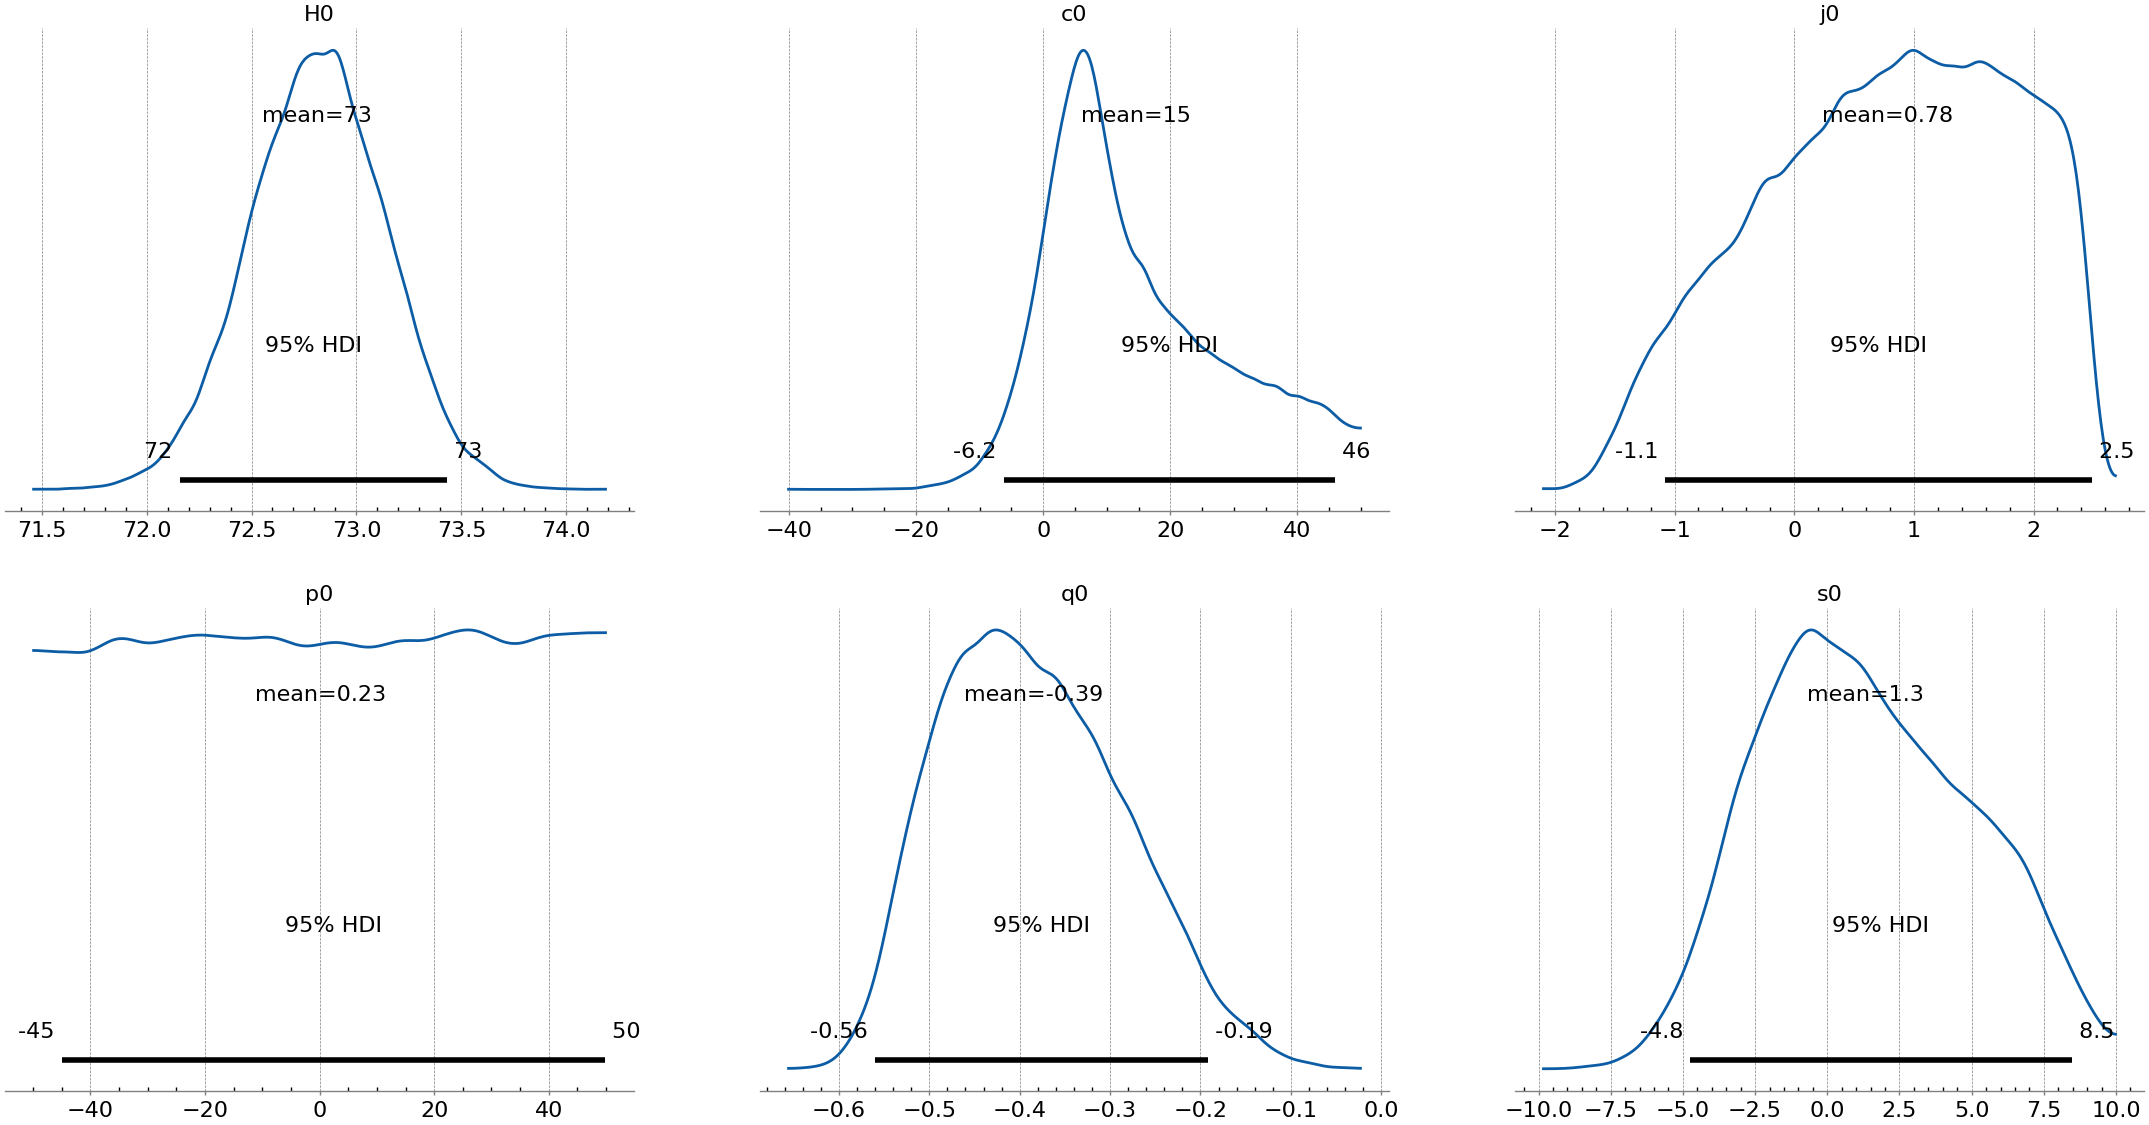

In [54]:
az.plot_posterior(idata, kind="kde", hdi_prob=0.95)


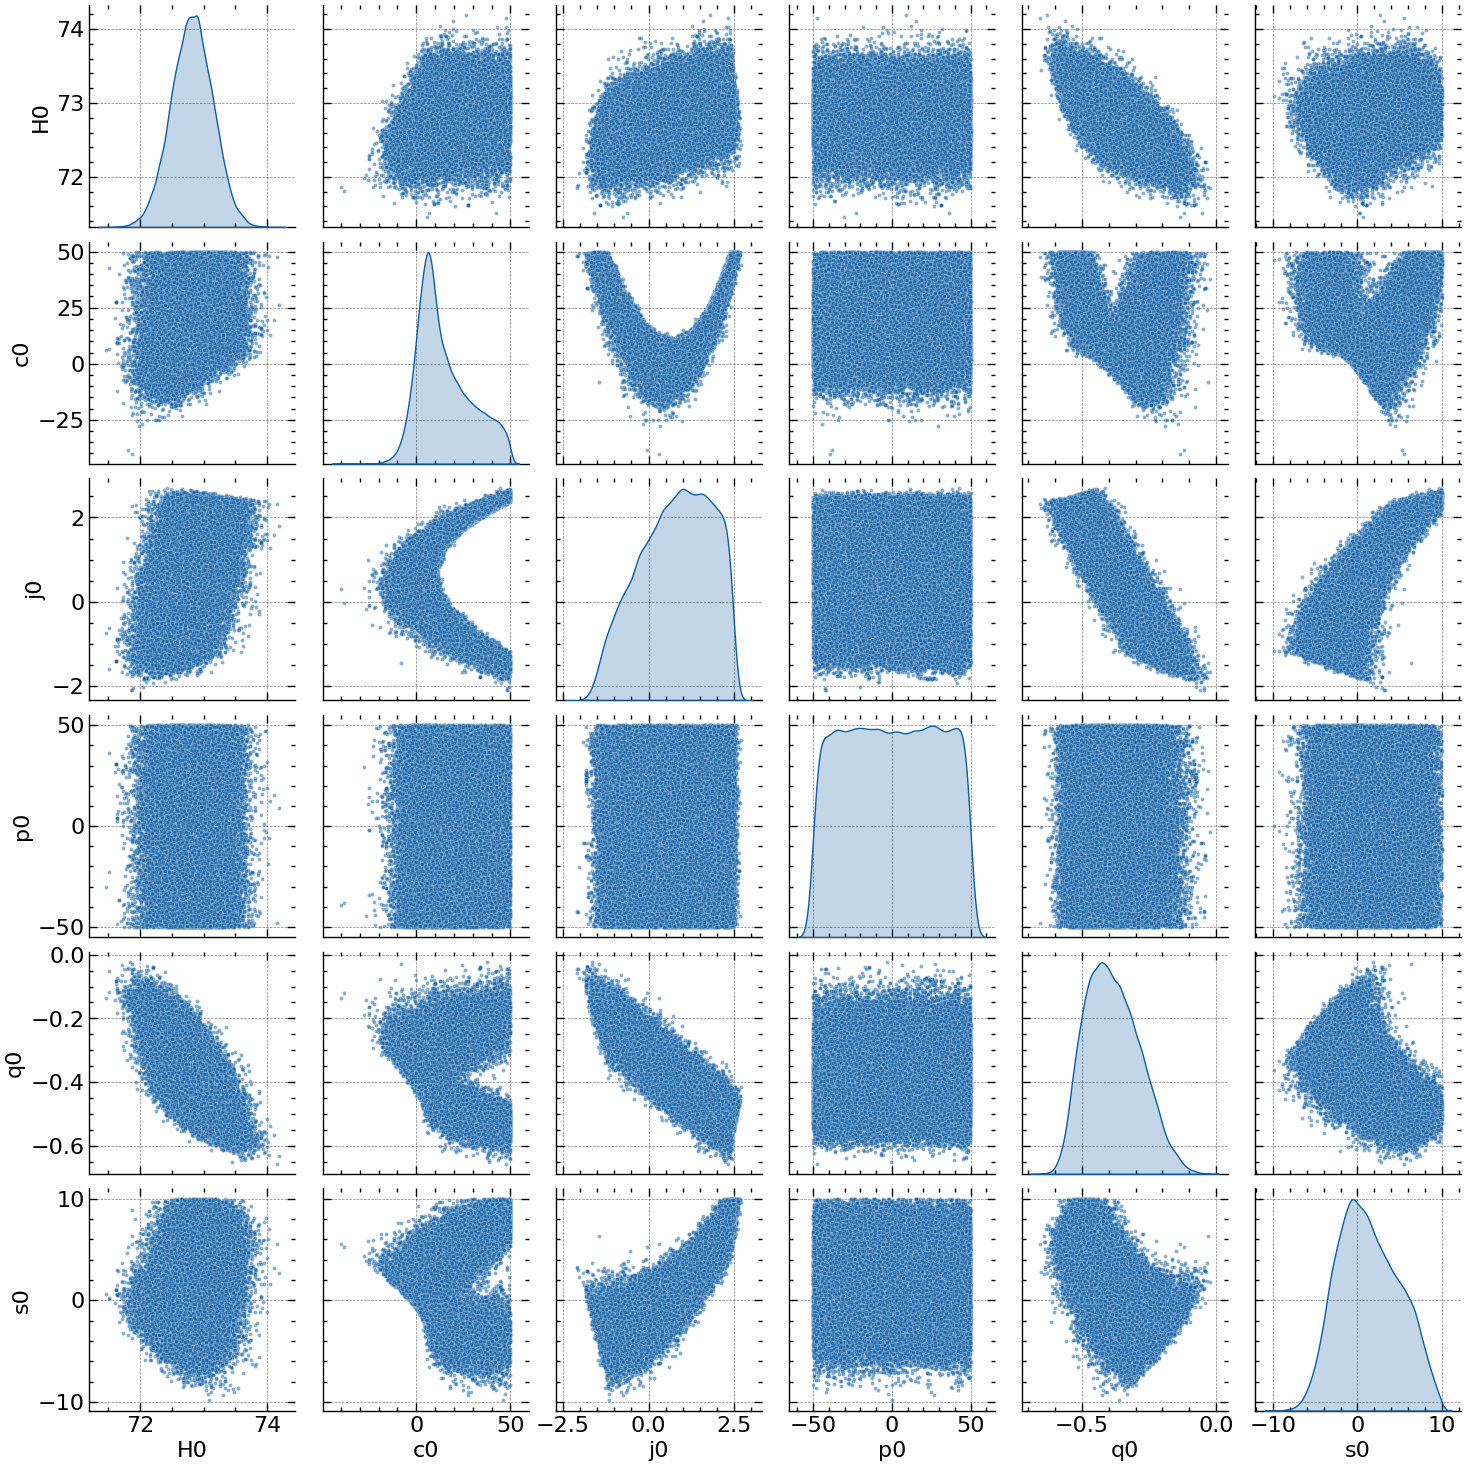

In [55]:
samples = mcmc.get_samples()
df = pd.DataFrame({k: np.array(v) for k, v in samples.items()})
import seaborn as sns
import matplotlib.pyplot as plt

sns.pairplot(
    df,
    diag_kind="kde",
    plot_kws={"alpha": 0.5, "s": 8}
)

plt.show()

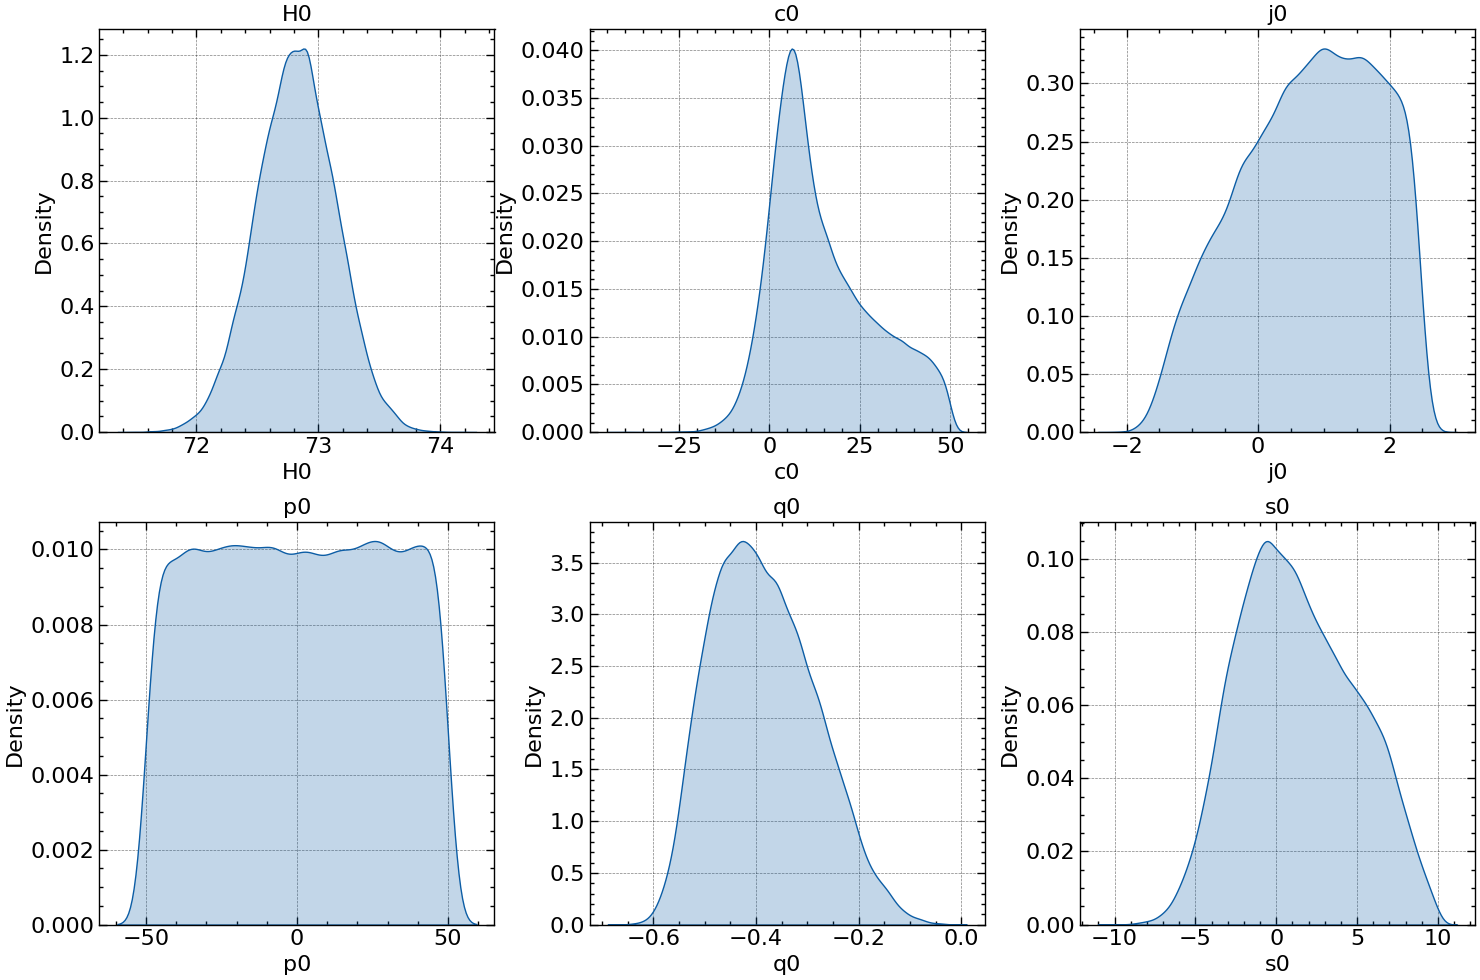

In [56]:
import math

params = df.columns
n = len(params)
cols = 3
rows = math.ceil(n / cols)

plt.figure(figsize=(15, 10))

for i, p in enumerate(params, 1):
    plt.subplot(rows, cols, i)
    sns.kdeplot(df[p], fill=True)
    plt.title(p)

plt.tight_layout()
plt.show()

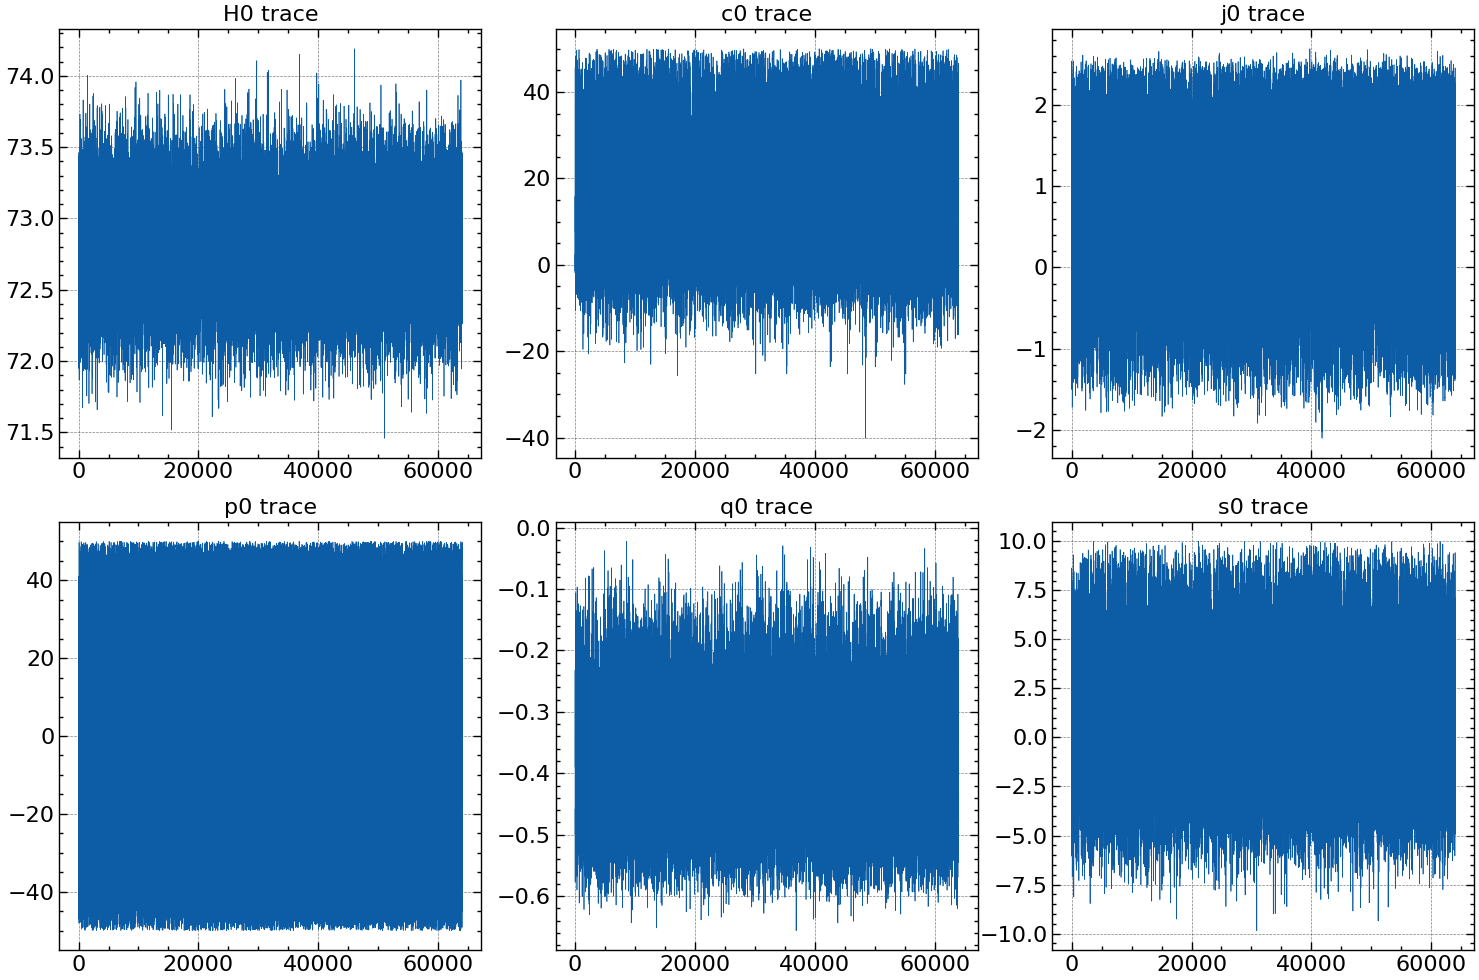

In [57]:
plt.figure(figsize=(15, 10))

for i, p in enumerate(params, 1):
    plt.subplot(rows, cols, i)
    plt.plot(df[p], linewidth=0.5)
    plt.title(p + " trace")

plt.tight_layout()
plt.show()


array([[<Axes: ylabel='H0'>, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
        <Axes: >],
       [<Axes: ylabel='q0'>, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
        <Axes: >],
       [<Axes: ylabel='j0'>, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
        <Axes: >],
       [<Axes: ylabel='s0'>, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
        <Axes: >],
       [<Axes: ylabel='c0'>, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
        <Axes: >],
       [<Axes: xlabel='H0', ylabel='p0'>, <Axes: xlabel='q0'>,
        <Axes: xlabel='j0'>, <Axes: xlabel='s0'>, <Axes: xlabel='c0'>,
        <Axes: xlabel='p0'>]], dtype=object)

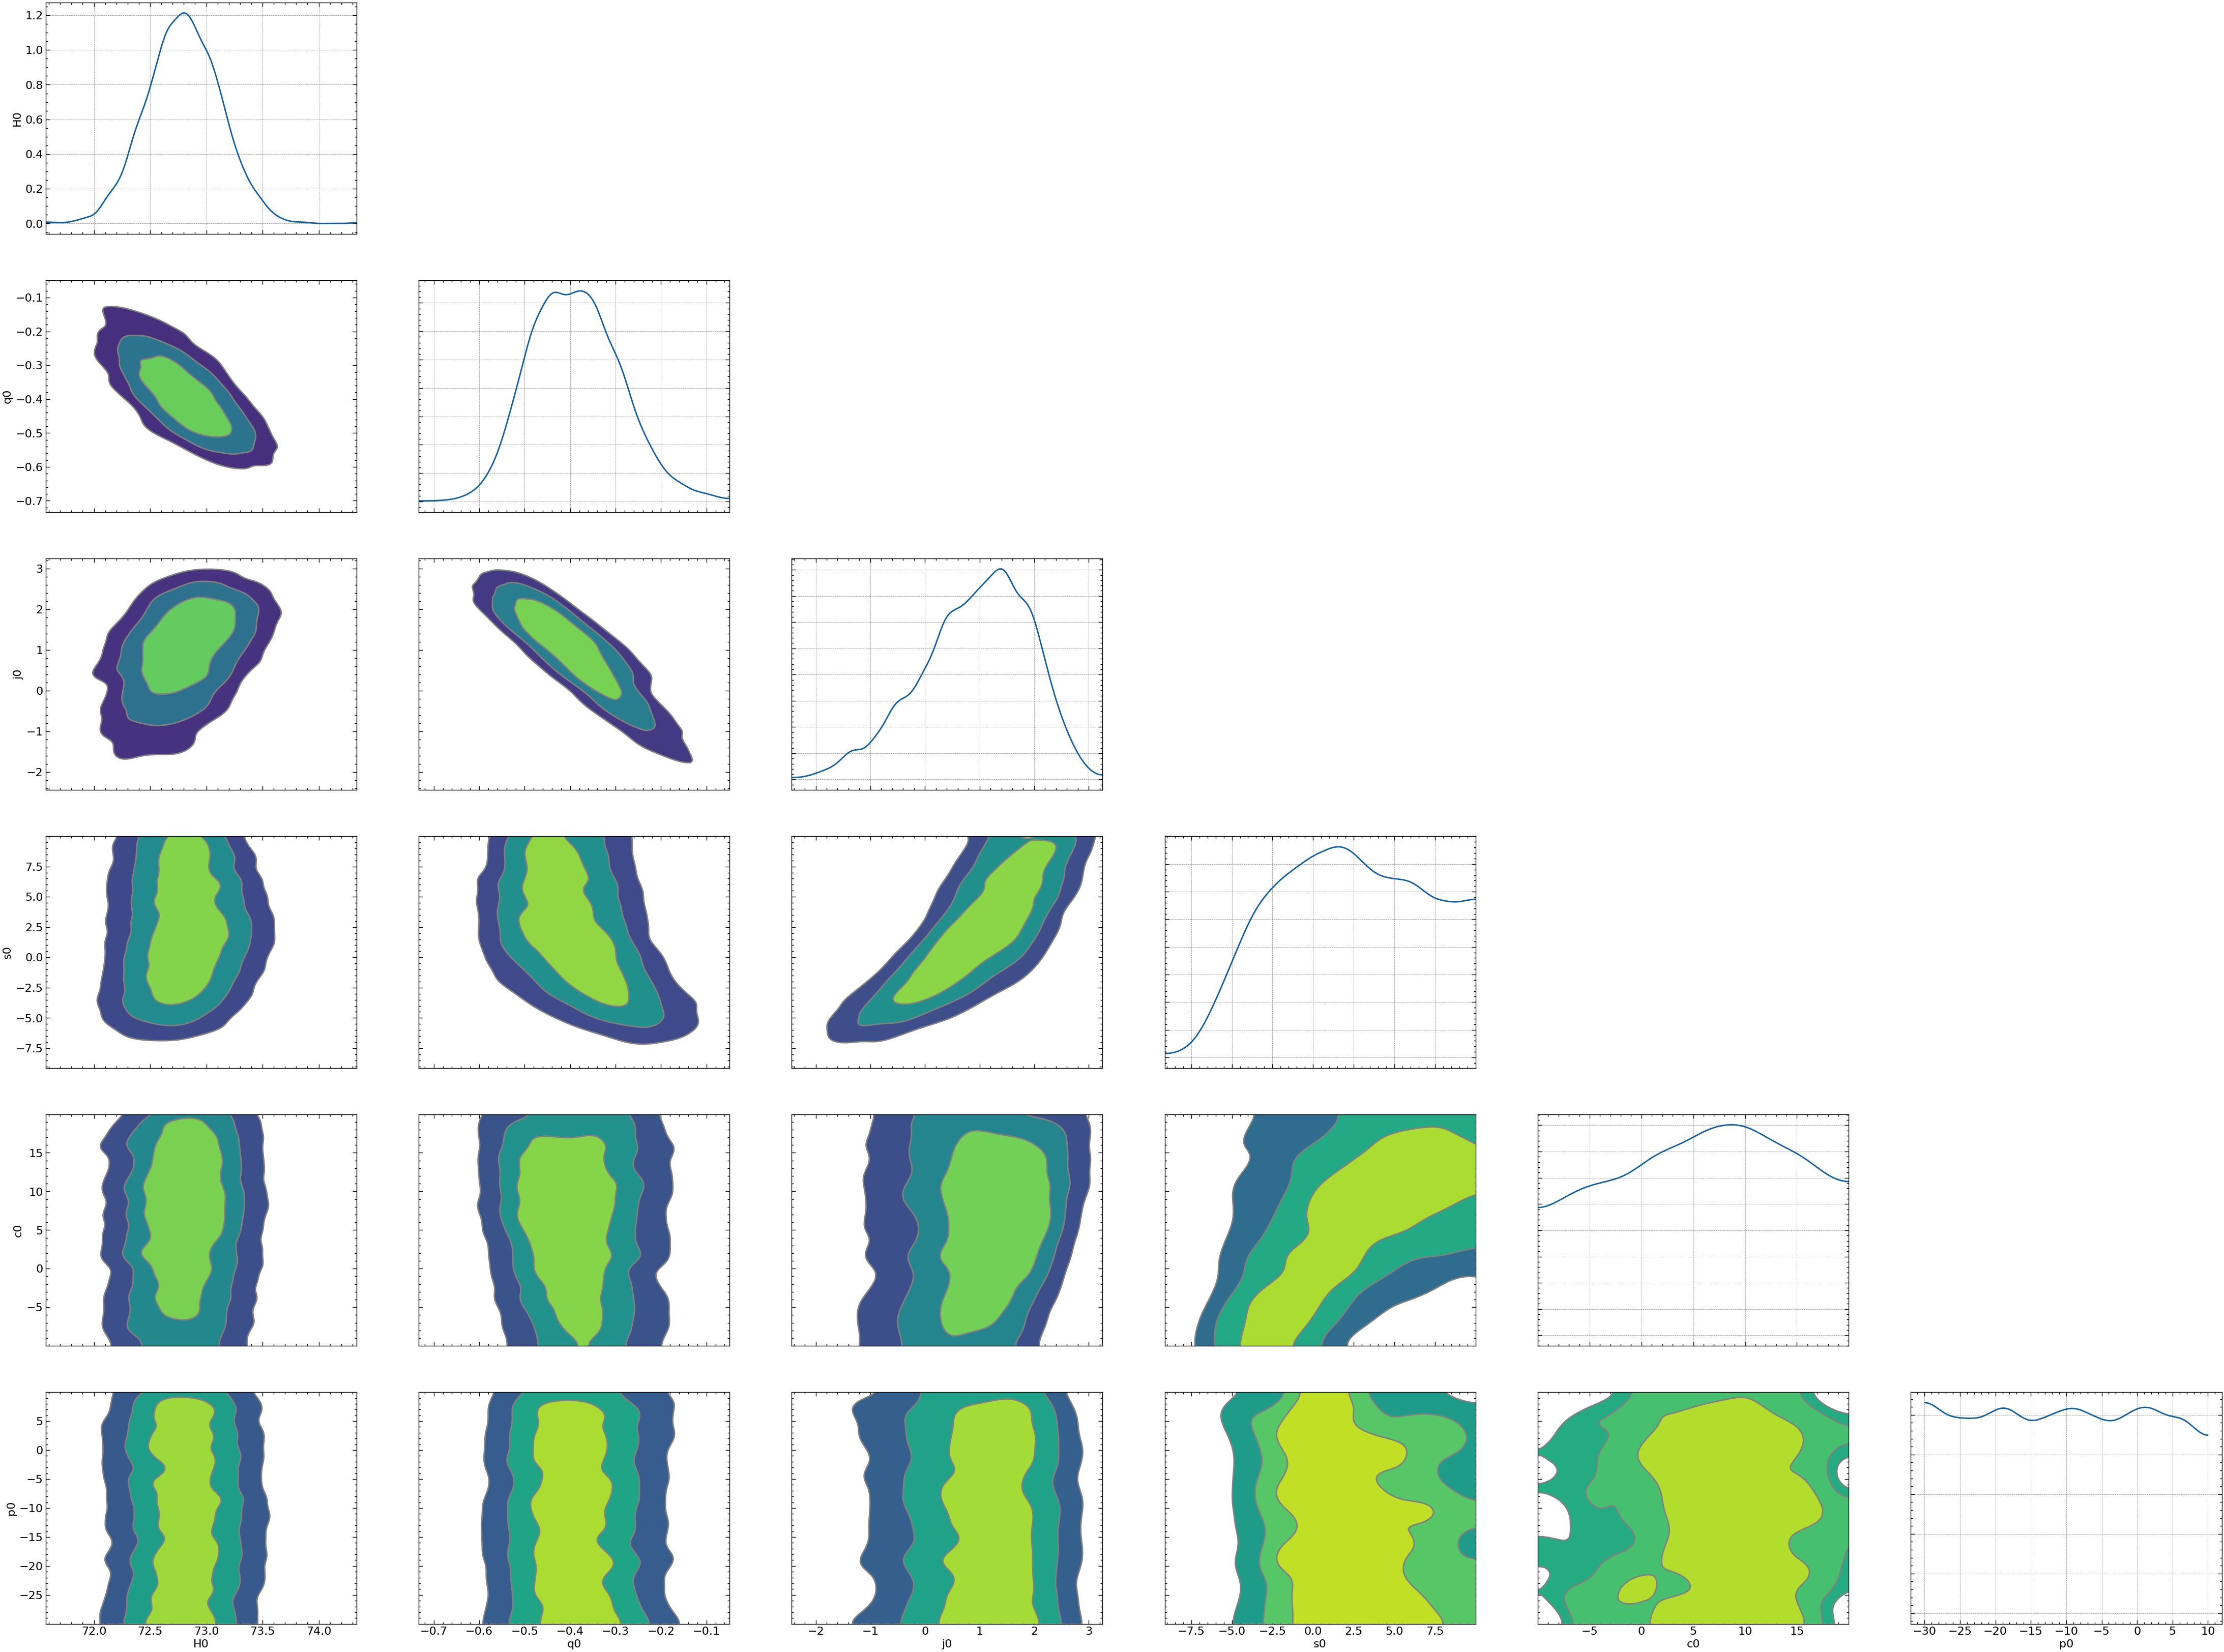

In [183]:
az.plot_pair(
    idata,
    var_names=["H0","q0","j0","s0","c0","p0"],
    kind="kde",
    marginals=True
)

array([[<Axes: ylabel='H0'>, <Axes: >, <Axes: >],
       [<Axes: ylabel='E1'>, <Axes: >, <Axes: >],
       [<Axes: xlabel='H0', ylabel='E2'>, <Axes: xlabel='E1'>,
        <Axes: xlabel='E2'>]], dtype=object)

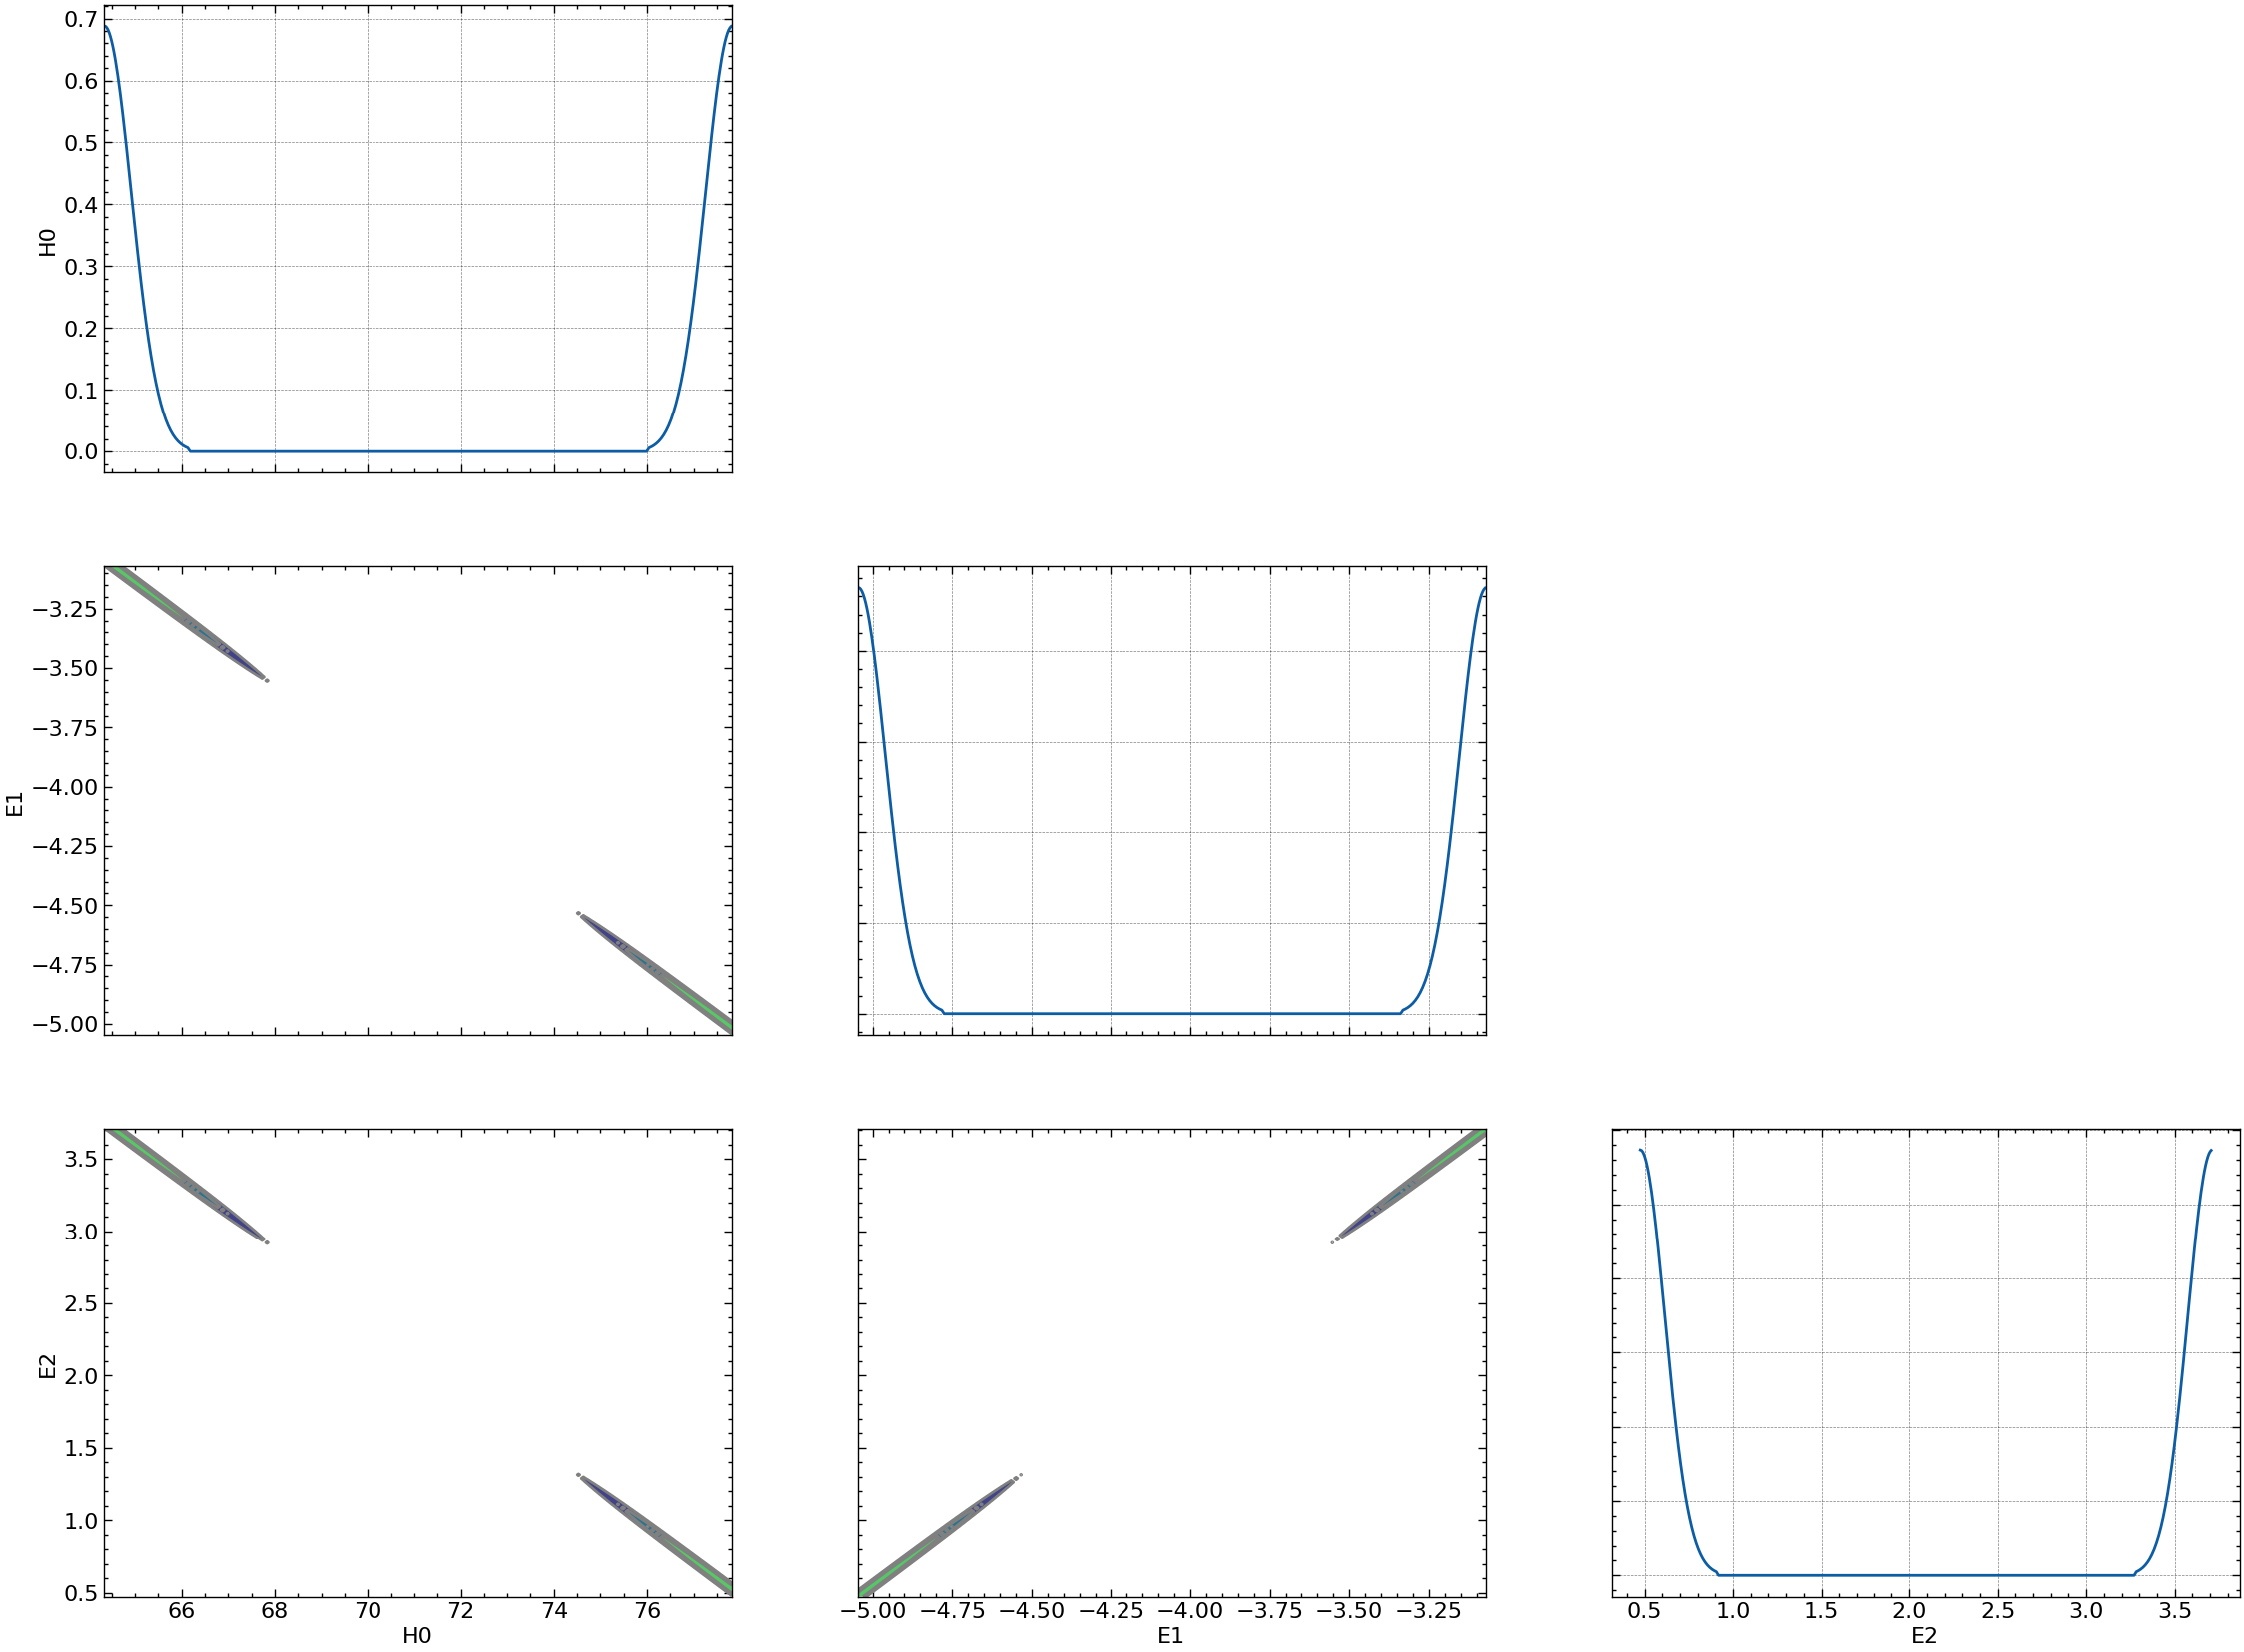